In [1]:
# importing the  requried libries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist


In [2]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [3]:
random_image = np.random.randint(0,len(X_train))
image = X_train[random_image]
print("kk image ",image)

kk image  [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  32 148 253 253 253 253 255 197  76   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 193 252 252 252 252 252 253 252 247 197
   23   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  43 227 252 252 252 252 252 253 252 252 252
  172   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 200 252 252 252 209 252 253 252 252 252
  242  56   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 164 217 241 101  25 

In [4]:
random_image

47102

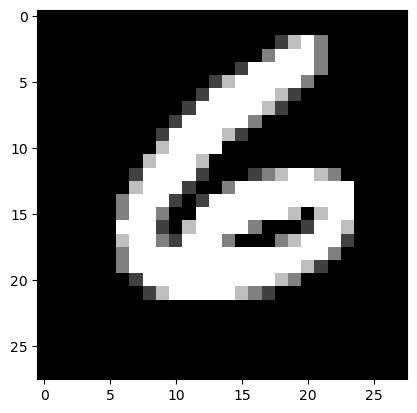

In [5]:
random_image = np.random.randint(0, len(X_train))

plt.imshow(X_train[random_image], cmap='gray')
plt.show()

In [6]:
(X_train.shape,y_train.shape),(X_test.shape,y_test.shape)

(((60000, 28, 28), (60000,)), ((10000, 28, 28), (10000,)))

In [7]:
# 0/255 = 0 , 255/255 = 1 # diving by 255 the images size on one range 
X_train = X_train/255
X_test = X_test/255

In [8]:
random_image = np.random.randint(0,len(X_train))
image = X_train[random_image]
print("kk image ",image)

kk image  [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.02745098 0.8
  0.99215686 0.78823529 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.32156863 0.98823529


In [9]:
# changeing the size of the image 
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [10]:
 import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
model = Sequential(
    [
        keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128,activation='relu'),
        keras.layers.Dense(10,activation='softmax')
        
    ]
)

C:\Users\abhia\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
 model.compile(
       optimizer='adam',
       loss = 'sparse_categorical_crossentropy',
       metrics = ['accuracy']
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

In [15]:
cal_back = EarlyStopping( monitor='val_loss',patience=8, restore_best_weights=True)

In [16]:
import datetime
from tensorflow.keras.callbacks import TensorBoard

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [18]:
 model.fit(X_train,y_train,validation_data=[X_test,y_test],epochs=8)

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9545 - loss: 0.1519 - val_accuracy: 0.9796 - val_loss: 0.0657
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9839 - loss: 0.0520 - val_accuracy: 0.9833 - val_loss: 0.0518
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9910 - loss: 0.0317 - val_accuracy: 0.9856 - val_loss: 0.0462
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9937 - loss: 0.0202 - val_accuracy: 0.9835 - val_loss: 0.0530
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9854 - val_loss: 0.0494
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9861 - val_loss: 0.0511
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9975 - loss: 0.0085 - val_accuracy: 0.9860 - val_loss: 0.0493
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9976 - loss: 0.0074 - 

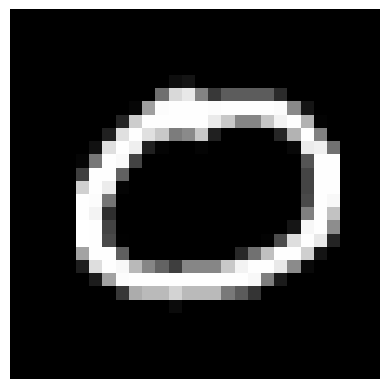

In [44]:
import numpy as np
import matplotlib.pyplot as plt

index = 69
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

In [46]:
prediction = model.predict(X_test[index].reshape(1, 28, 28, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [47]:
predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[index])

Predicted digit: 0
Actual digit: 0
